In [1]:
# General
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
import re
from datetime import date
import math
import geopandas as gpd

# Plotting
import matplotlib.pyplot as plt
import plotly
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

# Chart Studio
import chart_studio
chart_studio.tools.set_credentials_file(username='jfontes', api_key='RbrSLaCcCd8UsyIG09oP')
import chart_studio.plotly as py

In [2]:
# function to get unique values
def unique(list1):
 
    # initialize a null list
    unique_list = []
 
    # traverse for all elements
    for x in list1:
        # check if exists in unique_list or not
        if x not in unique_list:
            unique_list.append(x)
    return unique_list

In [3]:
# Define user
user = os.getlogin()
path_users = os.path.join('C:\\Users', user)

## Set file paths

# SharePoint
path_sp   = os.path.join(path_users, 'Sacramento Area Council of Governments\Regional Monitoring and Reporting - Documents')
path_agol = os.path.join(path_sp, 'Process Revamp', 'Task 8. Reproduce Progress Report indicators', 'Indicator Data', 'Census Data')
path_main = os.path.join(path_sp, 'Data')

# Git
path_git  = os.path.join(path_users, 'Documents', 'Projects', 'Regional-Monitoring', 'Indicator_Gen')
path_config = os.path.join(path_git, 'Python Code', 'Census', 'aa_config')

In [8]:
# Import objects
df_params = pd.read_excel(os.path.join(path_config, 'ACS Configuration File.xlsx'), sheet_name = 'Inputs')

# Set parameters for querying ACS data
indicator_name     = df_params[df_params['Type'] == 'indicator_name'    ]['Input'].values[0]
estimate           = df_params[df_params['Type'] == 'estimate'          ]['Input'].values[0]
sample_type        = df_params[df_params['Type'] == 'sample'            ]['Input'].values[0]
workbook           = df_params[df_params['Type'] == 'geography'         ]['Input'].values[0]
import_tab         = df_params[df_params['Type'] == 'import_tab'        ]['Input'].values[0]
percentages        = df_params[df_params['Type'] == 'percentages'       ]['Input'].values[0]
population_weights = df_params[df_params['Type'] == 'population_weights']['Input'].values[0]
num_vars           = df_params[df_params['Type'] == 'num_vars'          ]['Input'].values[0]
year_start         = df_params[df_params['Type'] == 'year_start'        ]['Input'].values[0]
year_end           = df_params[df_params['Type'] == 'year_end'          ]['Input'].values[0]
report_theme       = df_params[df_params['Type'] == 'report_theme'      ]['Input'].values[0]
sp_folder_out      = df_params[df_params['Type'] == 'sp_folder'         ]['Input'].values[0]


# view
print(indicator_name)
print(estimate)
print(sample_type)
print(workbook)
print(import_tab)
print("Percentages: " + percentages)
print("Population weights: " + population_weights)
print("Number of variables: " + str(num_vars))
print(year_start)
print(year_end)

Cost_6
ACS1
PUMS
PUMA
PUMA
Percentages: No
Population weights: No
Number of variables: 2
2021
2022


## Import Data

In [10]:
df_acs = pd.read_excel(os.path.join(path_main, report_theme, sp_folder_out, indicator_name,
                                  indicator_name + ' ' + workbook + ' ' + estimate + ' Households.xlsx')
                      # , sheet_name = import_tab
                      )

df_acs.columns = [x.lower() for x in df_acs.columns]
df_acs.columns = [re.sub('[\s+]', '_', col.strip()) for col in df_acs.columns]
# df_acs['percentage'] = round(df_acs['percentage'], 1)

print(df_acs.shape)
df_acs.head(3)

(217, 8)


,state_fips,mpo,year,hhldrrac1p,housing_type,housing_burden,wgtp,percentage
0,6,SACOG,2021,American Indian or Alaska Native (NH),N/A (GQ/vacant/not owned or being bought/occup...,N/A (GQ/vacant/not owned or being bought/occup...,9,100.000000
1,6,SACOG,2021,American Indian or Alaska Native (NH),Owner,Cost burden <=30%,809,75.678204
2,6,SACOG,2021,American Indian or Alaska Native (NH),Owner,Cost burden >30% to <=50%,204,19.083255


## Data Visualization

In [ ]:
# path_plots = os.path.join(path_main, report_theme, sp_folder_out, indicator_name, 'plots')


# if import_tab in ['MPO']:
#     df_plot = df_acs[['year', 'variable', 'race_ethnicity', 'percentage']]
#     df_plot = df_plot[df_plot['race_ethnicity'] != 'All']
#     color = 'race_ethnicity'
#     labels = 'race_ethnicity'

# if import_tab in ['MSA', 'Counties']:
#     if import_tab == 'Counties':
#         df_plot = df_acs[['year', 'county_name', 'variable', 'race_ethnicity', 'percentage']]
#         color = 'county_name' 
#         labels = 'county_name'
#     if import_tab == 'MSA':
#         df_plot = df_acs[['year', 'msa', 'variable', 'race_ethnicity', 'percentage']]
#         color = 'msa' 
#         labels = 'msa'

#     df_plot = df_plot[df_plot['race_ethnicity'] == 'All'].drop('race_ethnicity', axis = 1)



# x = 'year'
# y = 'percentage'

# vars = unique(df_plot['variable'].values)

# for variable in vars:
#     df_plot_plot = df_plot[df_plot['variable'] == variable]
    
#     fig = px.line(df_plot_plot
#                      , x = x
#                      , y = y
#                      , color = color
#                      # , line_dash = line_dash
#                      , markers = True
#                      , labels = labels
#                     )
    
#     if import_tab in ['MPO']:   
#         fig.update_layout(title = variable + ' (%) by Race/Ethnicity')

#     if import_tab in ['Counties', 'MSA']:
#         fig.update_layout(title = variable + ' (%)  by ' + import_tab)
    

#     if import_tab in ['MPO']:
#         fig.write_html(
#             os.path.join(
#                 path_plots
#                 , ''.join([indicator_name + '_'
#                            , variable  + '_'
#                            , 'SACOG by Race' + '_'
#                            , 'line_'
#                            , '.html'])
#             )
#         )
#         py.plot(fig, filename = ''.join([indicator_name + '_'
#                            , variable  + '_'
#                            , 'SACOG by Race' + '_'
#                            , 'line_'
#                            , '.html']))
        
#     if import_tab == 'MSA':
#         fig.write_html(
#             os.path.join(
#                 path_plots
#                 , ''.join([indicator_name + '_'
#                            , variable  + '_'
#                            , 'by Peer MSAs_'
#                            , 'line_'
#                            , '.html'])
#             )
#         )
#         py.plot(fig, filename = ''.join([indicator_name + '_'
#                            , variable  + '_'
#                            , 'by Peer MSAs_'
#                            , 'line_'
#                            , '.html']))

#     if import_tab == 'Counties':
#         fig.write_html(
#             os.path.join(
#                 path_plots
#                 , ''.join([indicator_name + '_'
#                            , variable  + '_'
#                            , 'by SACOG Counties_'
#                            , 'line_'
#                            , '.html'])
#             )
#         )
#         py.plot(fig, filename = ''.join([indicator_name + '_'
#                            , variable  + '_'
#                            , 'by SACOG Counties_'
#                            , 'line_'
#                            , '.html']))

# fig.show()

In [ ]:
df_plot = df_acs[df_acs['race_ethnicity'] != 'All']
df_plot = df_plot[df_plot['variable'] == 'Owner occupied']

x = 'year'
y = 'percentage'
color = 'race_ethnicity'
line_dash = 'mpo'
variable = 'Owner occupied'
labels = 'race_ethnicity'

fig = px.line(df_plot
              , x = x
              , y = y
              , color = color
              , line_dash = line_dash
              , markers = True
              , labels = labels
                    )

fig.update_layout(title = 'Owner occupied households (%) by MPOs by Race/Ethnicity')


# py.plot(fig, filename = ''.join([indicator_name + '_'
#                            , variable  + '_'
#                            , 'MPO by Race-Ethnicity' + '_'         
#                            , 'line_'
#                            , '.html']))


fig.show()



In [ ]:
# Subset the data for specific bar plot
# Make bar plots
# Export to Chart Studio to put in dashboard

df_plot = df_acs[df_acs['race_ethnicity'] != 'All']
df_plot = df_plot[df_plot['variable'] == 'Owner occupied']

df_plot = df_plot[df_plot['year'].isin([2012, 2017, 2022])]
df_plot = df_plot.sort_values('year', ascending = True)

x = 'year'
y = 'percentage'
color = 'race_ethnicity'
variable = 'Owner occupied'
facet_col = 'mpo'


fig = px.bar(df_plot
             , x = x
             , y = y
             , color = color
             , facet_col = facet_col
             , barmode = 'group'
             # , labels={'County': '', 'Value':'Population'}
            )

fig.update_layout(title = 'Owner occupied households (%) by MPO')

fig.update_layout(
    autosize=False,
    width=1100,
    height=350
)


fig.show()
# py.plot(fig, filename = ''.join([indicator_name + '_'
#                            , variable  + '_'
#                            , 'MPO by Race-Ethnicity' + '_'         
#                            , 'bar_'
#                            , '.html']))

In [ ]:
df_acs.head()

In [ ]:
unique(df_acs.housing_burden.values)

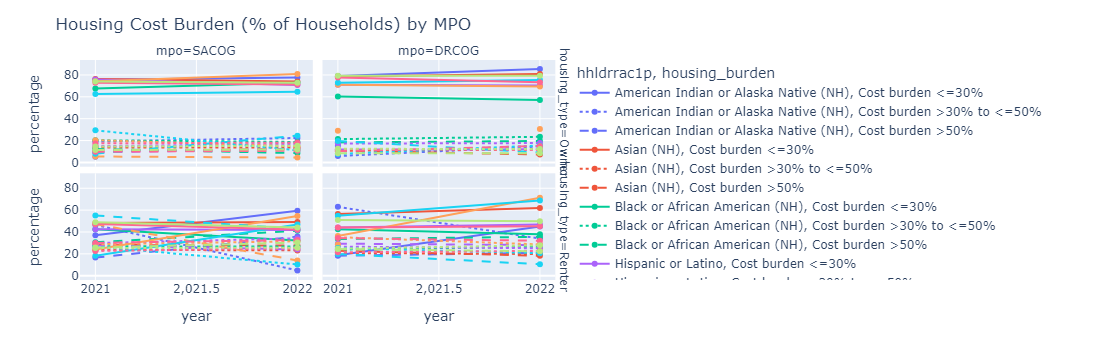

In [16]:
df_plot = df_acs[df_acs['housing_type'].isin(['Renter', 'Owner'])]

x = 'year'
# y = 'wgtp'
y = 'percentage'
color = 'hhldrrac1p'
line_dash = 'housing_burden'
labels = 'housing_burden'
variable = 'Housing cost burden'
facet_row = 'housing_type'
facet_col = 'mpo'



fig = px.line(df_plot
              , x = x
              , y = y
              , color = color
              , line_dash = line_dash
              , markers = True
              # , labels = labels
              , facet_col = facet_col
              , facet_row = facet_row
                    )

fig.update_layout(title = 'Housing Cost Burden (% of Households) by MPO')


# py.plot(fig, filename = ''.join([indicator_name + '_'
#                            , variable  + '_'
#                            , 'MPO' + '_'         
#                            , 'line_'
#                            , '.html']))


fig.show()

#### Code graveyard

In [ ]:
# path_plots = os.path.join(path_main, report_theme, sp_folder_out, indicator_name, 'plots')

# def plot_lines(data, indicator_name, estimate, x, y, group, variables):

#     df_plot = data.copy()
#     color  = group
#     labels = group
#     vars   = unique(variables)
#     x = x
#     y = y
#     vars = unique(df_plot[variables].values)

#     if group == 'race_ethnicity':
#         df_plot = df_plot[df_plot['race_ethnicity'] != 'All']
#         df_plot = df_plot[['year', 'variable', 'race_ethnicity', 'percentage']]
#         df_plot = df_plot[df_plot['race_ethnicity'] != 'All']

#     if group in ['MSA', 'County']:
#         if group == 'County':
#             df_plot = df_plot[['year', 'county_name', 'variable', 'race_ethnicity', 'percentage']]
#         if group == 'MSA':
#             df_plot = df_plot[['year', 'msa', 'variable', 'race_ethnicity', 'percentage']]
#         df_plot = df_plot[df_plot['race_ethnicity'] == 'All'].drop('race_ethnicity', axis = 1)       


#     for var in vars:
#         df_plot2 = df_plot[df_plot['variable'] == var]
        
#         fig = px.line(df_plot2
#                          , x = x
#                          , y = y
#                          , color = color
#                          , markers = True
#                          , labels = group
#                         )
            
#         fig.update_layout(title = var + ' by ' + group)
        
#         fig.write_html(
#             os.path.join(
#                 path_plots
#                 , ''.join([indicator_name + '_'
#                            , var  + '_'
#                            , group + '_'
#                            , estimate  + '_'
#                            , 'line_'
#                            , '.html'])
#             )
#         )
    

In [ ]:
# plot_lines(data = df_acs
#            , indicator_name = indicator_name
#            , estimate = estimate
#            , x = 'year'
#            , y = 'percentage'
#            , group = 'county_name'
#            , variables = 'variable')